In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [ ]:
import matplotlib
import numpy
import os
import pandas
import random
import sys
import torch
import transformers

In [ ]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

from innoprod.plotting_tools import rand_jitter
from innoprod.random_tools import get_os_random_seed, set_all_random_seeds
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.text_analysis.bert_multiple_choice_wrapper import BertMultipleChoiceWrapper, default_model_and_tokenizer
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps
from innoprod.wrangling.wrangling_tools import is_non_empty

In [ ]:
model_name = "pborchert/BusinessBERT"

In [ ]:
data = get_sheet_dfs()
roadmaps_df = wrangle_roadmaps(data['Roadmaps'])

In [ ]:
drs_data = roadmaps_df[[
    'Client ID',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Current Digital Readiness Score (refer to PAS:1040)',
    ]].rename(columns={
        'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples': 'Context',
        'Current Digital Readiness Score (refer to PAS:1040)': 'DRS',
    })

drs_data = drs_data[drs_data['DRS'].notna() & is_non_empty(drs_data['Context'])]

In [31]:
prompt = drs_data['Context'].to_list()[0]
prompt

"The website, product database, ERP and warehouse management system are all built in-house and thus their team of software developers are a core part of the company's ability to make changes. Technological investments have also been made in barcode scanning."

In [32]:
drs_data['DRS'].to_list()[0]

5

The DRS levels from [PAS 1040:2019 Digital Technologies in Manufacturing](https://www.bsigroup.com/en-GB/insights-and-media/insights/brochures/pas-1040-adopting-digital-technologies-in-manufacturing-guide/) Table 6.

In [ ]:
choices = [
    "The business has no vision for driving growth with digital technologies, and is not supporting workers to investigate opportunities.", # 1
    "Workers are aware of the potential for digital technologies and are supported by the business to experiment with local trials.", # 2
    "The business is learning from local trials of digital technologies and leaders are investigating the business case.", # 3
    "The business has a strategic vision for digital transformation, the business case is agreed and implementation is underway.", # 4
    "Workers are engaged in digital transformation and the business is starting to achieve business case benefits.", # 5
    "Digital technologies are driving continuous improvement in key aspects of operational performance including supply chain and customer services.", # 6
    "Innovation with digital technologies is part of the culture of the business and is driving continuous improvement in all aspects.", # 7
    "Increasing adoption of digital technologies is sustained by reinvestment of related profits and continuous renewal of the business case.", # 8
    "Digital technologies are driving optimized productivity and competitiveness for the business and its partners.", # 9
]


In [19]:
n_runs = 10
results = None
seeds = [get_os_random_seed() for i in range(n_runs)]
for i in range(n_runs):
  set_all_random_seeds(seeds[i])
  model, tokenizer = default_model_and_tokenizer(model_name)
  bert_wrapper = BertMultipleChoiceWrapper(model, tokenizer, choices)
  bert_wrapper.predict(prompt)
  run_results = bert_wrapper.get_results()
  if results is None:
      results = run_results
  else:
      results = pandas.concat([results, run_results])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: pborchert/BusinessBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: pborchert/BusinessBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForMultipleChoice LOAD REPORT from: pborchert/BusinessBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: pborchert/BusinessBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: pborchert/BusinessBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identi

In [20]:
results

,context,random_seed,"The business has no vision for driving growth with digital technologies, and is not supporting workers to investigate opportunities.",Workers are aware of the potential for digital technologies and are supported by the business to experiment with local trials.,The business is learning from local trials of digital technologies and leaders are investigating the business case.,"The business has a strategic vision for digital transformation, the business case is agreed and implementation is underway.",Workers are engaged in digital transformation and the business is starting to achieve business case benefits.,Digital technologies are driving continuous improvement in key aspects of operational performance including supply chain and customer services.,Innovation with digital technologies is part of the culture of the business and is driving continuous improvement in all aspects.,Increasing adoption of digital technologies is sustained by reinvestment of related profits and continuous renewal of the business case.,Digital technologies are driving optimized productivity and competitiveness for the business and its partners.
0,"The website, product database, ERP and warehou...",2321080443,0.075865,0.135017,0.022876,0.204559,0.113457,0.099216,0.216015,0.093457,0.153651
0,"The website, product database, ERP and warehou...",3020150100,0.282495,0.297788,0.245495,0.216517,0.270409,0.314904,0.324067,0.240025,0.259115
0,"The website, product database, ERP and warehou...",206900678,0.240500,0.286742,0.294731,0.425602,0.131292,0.339362,0.183095,0.252626,0.121575
0,"The website, product database, ERP and warehou...",1169595699,0.146361,0.013700,0.234379,0.154186,0.222611,0.140041,0.190679,0.134512,0.114809
0,"The website, product database, ERP and warehou...",1679510495,0.267786,0.333828,0.214580,0.274587,0.192181,0.363265,0.314677,0.319082,0.302495
0,"The website, product database, ERP and warehou...",4179594605,0.201377,0.258884,0.181181,0.151742,0.155823,-0.049874,-0.171281,0.033673,-0.002174
0,"The website, product database, ERP and warehou...",831635748,-0.341804,-0.357734,-0.276113,-0.319571,-0.267455,-0.064591,-0.131518,-0.247092,-0.151284
0,"The website, product database, ERP and warehou...",1339281110,0.432539,0.469909,0.450718,0.494131,0.427091,0.355694,0.440344,0.380720,0.330121
0,"The website, product database, ERP and warehou...",2059347350,-0.098246,-0.211424,0.001866,-0.161069,-0.036894,-0.346542,-0.339489,-0.220405,-0.199005
0,"The website, product database, ERP and warehou...",352311651,0.462041,0.468632,0.575072,0.480135,0.571994,0.357051,0.431773,0.410930,0.393119


Running over the whole dataset takes about 10 minutes. Uncomment the code cell below to analyse just 10 rows in about half a minute.

,0
0,[Line2D(_child0)]
0,[Line2D(_child1)]
0,[Line2D(_child2)]
0,[Line2D(_child3)]
0,[Line2D(_child4)]
0,[Line2D(_child5)]
0,[Line2D(_child6)]
0,[Line2D(_child7)]
0,[Line2D(_child8)]
0,[Line2D(_child9)]


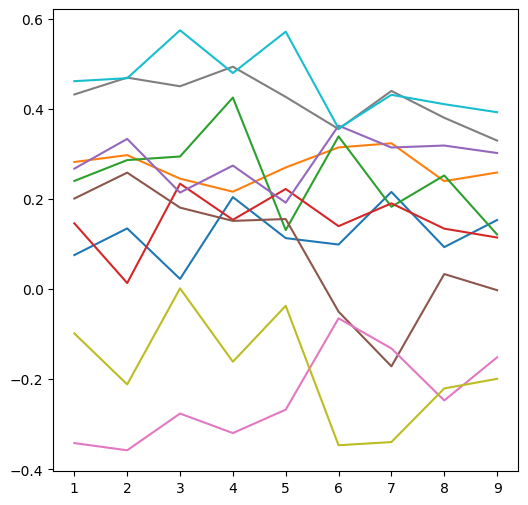

In [29]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

x = list(range(1,10))
results[choices].apply(lambda row: ax.plot(x, row, zorder=0), axis=1)

In [30]:
sum_results = results[choices].sum()
sum_results

,0
"The business has no vision for driving growth with digital technologies, and is not supporting workers to investigate opportunities.",1.668914
Workers are aware of the potential for digital technologies and are supported by the business to experiment with local trials.,1.695343
The business is learning from local trials of digital technologies and leaders are investigating the business case.,1.944785
"The business has a strategic vision for digital transformation, the business case is agreed and implementation is underway.",1.920820
Workers are engaged in digital transformation and the business is starting to achieve business case benefits.,1.780509
Digital technologies are driving continuous improvement in key aspects of operational performance including supply chain and customer services.,1.508525
Innovation with digital technologies is part of the culture of the business and is driving continuous improvement in all aspects.,1.458362
Increasing adoption of digital technologies is sustained by reinvestment of related profits and continuous renewal of the business case.,1.397530
Digital technologies are driving optimized productivity and competitiveness for the business and its partners.,1.322422


In [ ]:
# drs_data = drs_data[:10].copy(deep=True)
# len(drs_data)

In [ ]:
drs_data['scores'] = drs_data['Context'].apply(calc_choice_scores)

In [ ]:
for i in range(len(choices)):
  drs_data[f'DRS_{i+1}'] = drs_data['scores'].apply(lambda x: x[i])
drs_data['DRS_pred'] = drs_data['scores'].apply(lambda x: x.index(max(x))+1)


In [ ]:
x = drs_data['DRS'].values.reshape(-1, 1)
y = drs_data['DRS_pred'].values.reshape(-1, 1)

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

stdev = 0.2
ax.scatter(
    rand_jitter(x, stdev=stdev),
    rand_jitter(y, stdev=stdev),
    c=((drs_data['DRS'].values+drs_data['DRS_pred'].values)%2),
    zorder=0
  )

ax.plot([1,9], [1,9], zorder=1, c='r')

ax.set_xlabel('DRS')
ax.set_ylabel('BERT-predicted DRS')

In [ ]:
drs_data['DRS'].value_counts().sort_index().plot(kind="bar")

In [ ]:
drs_data['DRS_pred'].value_counts().sort_index().plot(kind="bar")